# Deep Learning from Scratch with NumPy
## House Price Prediction - bài tập mở rộng theo notebook mẫu

Notebook xây dựng MLP **5 tầng có tham số** hoàn toàn bằng NumPy:

$$X(B,d)\rightarrow H_1(B,128)\rightarrow H_2(B,64)\rightarrow H_3(B,32)\rightarrow H_4(B,16)\rightarrow \hat y(B,1)$$

Mục tiêu là dự báo `price_million_vnd`. Tầng ra tuyến tính, loss là MSE trên $\log(1+price)$. Notebook có train/validation/test 70/15/15, Adam, gradient clipping, early stopping, baseline và các exercise tương tự bài Diabetes mẫu.

## 1. Import và cấu hình

In [1]:
from pathlib import Path
import copy, time, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("ignore")
SEED = 42
rng = np.random.default_rng(SEED)
sns.set_theme(style="whitegrid")
HERE = Path.cwd()
DATA_DIR = HERE / "upload" if (HERE / "upload").exists() else HERE
MODEL_DIR = HERE / "models"
MODEL_DIR.mkdir(exist_ok=True)

# True: chạy nhanh để học/thử. False: dùng cấu hình báo cáo cuối.
FAST_MODE = True
print("FAST_MODE =", FAST_MODE)

FAST_MODE = True


## 2. Load và kiểm tra dữ liệu

Một dòng là một tin đăng nhà. `id`, `detail_url`, `title` không dùng làm feature: ID/URL không khái quát; title có thể chứa trực tiếp giá và gây leakage.

In [2]:
df=pd.read_csv(DATA_DIR/"gianha_02.csv")
print("Shape:",df.shape); display(df.head()); df.info()
display(df.describe(include="all").T)
display(df.isna().sum().to_frame("missing")); print("Duplicates:",df.duplicated().sum())

Shape: (66912, 11)


,id,detail_url,title,location,timeline_hours,area_m2,bedrooms,bathrooms,floors,frontage,price_million_vnd
0,196958,https://batdongsan.vn/ban-nha-nguyen-son-long-...,Bán nhà Nguyễn Sơn Long Biên- Dân trí Tuyệt vờ...,"Long Biên, Hà Nội",2,50.0,4.0,4.0,6.0,False,12500.0
1,196967,https://batdongsan.vn/ban-nha-hem-xe-hoi-4m-2-...,"BÁN NHÀ HẺM XE HƠI 4M, 2 MẶT TIỀN - 2 TẦNG , N...","Bình Chánh, Hồ Chí Minh",2,98.0,4.0,4.0,3.0,True,5500.0
2,196983,https://batdongsan.vn/o-to-ngu-nha-62m2-5-tang...,Ô TÔ NGỦ NHÀ – 62M² – 5 Tầng/4PN – Gần kdc CIT...,"Gò Vấp, Hồ Chí Minh",2,62.0,4.0,5.0,6.0,False,8740.0
3,196962,https://batdongsan.vn/ban-nha-phuc-loi-ngo-non...,Bán nhà Phúc Lợi - ngõ nông - ô tô vào nhà - t...,"Long Biên, Hà Nội",2,39.0,3.0,4.0,6.0,False,6500.0
4,196972,https://batdongsan.vn/tran-duy-hung-6-tang-tha...,TRẦN DUY HƯNG - 6 TẦNG THANG MÁY - NGÕ THÔNG D...,"Cầu Giấy, Hà Nội",2,45.0,3.0,3.0,7.0,True,16980.0


<class 'pandas.DataFrame'>
RangeIndex: 66912 entries, 0 to 66911
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 66912 non-null  int64  
 1   detail_url         66905 non-null  str    
 2   title              66912 non-null  str    
 3   location           66912 non-null  str    
 4   timeline_hours     66912 non-null  int64  
 5   area_m2            50344 non-null  float64
 6   bedrooms           55273 non-null  float64
 7   bathrooms          51548 non-null  float64
 8   floors             52278 non-null  float64
 9   frontage           66912 non-null  bool   
 10  price_million_vnd  64809 non-null  float64
dtypes: bool(1), float64(5), int64(2), str(3)
memory usage: 18.9 MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,66912.0,NaN,NaN,NaN,141092.732768,32545.265005,80084.0,116152.75,142310.0,168691.5,197061.0
detail_url,66905,66905,https://batdongsan.vn/ban-nha-nguyen-son-long-...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,66912,66899,✨ TINH HOA TRẦN VĂN QUANG - HXH – 4 TẦNG BTCT...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,66912,280,"Gò Vấp, Hồ Chí Minh",3441,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timeline_hours,66912.0,NaN,NaN,NaN,8749.222666,6863.201079,2.0,3600.0,7200.0,8760.0,26280.0
area_m2,50344.0,NaN,NaN,NaN,1377.9767,276334.663515,1.0,42.0,60.0,92.0,62000000.0
bedrooms,55273.0,NaN,NaN,NaN,4.429649,4.500243,1.0,3.0,4.0,5.0,127.0
bathrooms,51548.0,NaN,NaN,NaN,4.296617,4.618477,1.0,2.0,3.0,5.0,127.0
floors,52278.0,NaN,NaN,NaN,14775.954379,3377398.558508,0.0,3.0,4.0,6.0,772221339.0
frontage,66912,2,False,52086,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,missing
id,0
detail_url,7
title,0
location,0
timeline_hours,0
area_m2,16568
bedrooms,11639
bathrooms,15364
floors,14634
frontage,0


Duplicates: 0


## 3. Làm sạch, chia dữ liệu và biểu diễn

- Xóa bản ghi trùng và nhãn thiếu/không dương.
- Giá có đuôi phải rất dài nên học trên `log1p(price)`.
- Chia trước, rồi fit median/one-hot/scaler trên **train** để tránh leakage.
- Để MLP NumPy chạy được, categorical được one-hot thành ma trận dense.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

target="price_million_vnd"
features=["location","timeline_hours","area_m2","bedrooms","bathrooms","floors","frontage"]
num_cols=["timeline_hours","area_m2","bedrooms","bathrooms","floors"]
cat_cols=["location","frontage"]
df=df.drop_duplicates(); df=df[df[target].notna()&(df[target]>0)].copy()
for c in ["area_m2","bedrooms","bathrooms","floors"]: df.loc[df[c]<=0,c]=np.nan
X=df[features]; y=np.log1p(df[target].to_numpy(np.float32)).reshape(-1,1)
Xtr,Xtmp,ytr,ytmp=train_test_split(X,y,test_size=.30,random_state=SEED)
Xv,Xte,yv,yte=train_test_split(Xtmp,ytmp,test_size=.50,random_state=SEED)
prep=ColumnTransformer([
 ("num",Pipeline([("imp",SimpleImputer(strategy="median")),("scale",StandardScaler())]),num_cols),
 ("cat",Pipeline([("imp",SimpleImputer(strategy="most_frequent")),("oh",OneHotEncoder(handle_unknown="ignore",sparse_output=False))]),cat_cols)
],sparse_threshold=0)
Xtr=prep.fit_transform(Xtr).astype(np.float32); Xv=prep.transform(Xv).astype(np.float32); Xte=prep.transform(Xte).astype(np.float32)
if FAST_MODE and len(Xtr)>20000:
    idx=rng.choice(len(Xtr),20000,replace=False); Xtr,ytr=Xtr[idx],ytr[idx]
print("Train/Val/Test:",Xtr.shape,Xv.shape,Xte.shape,"Target:",ytr.shape)
print("One house vector first 15 values:",Xtr[0,:15])

Train/Val/Test: (20000, 257) (9667, 257) (9668, 257) Target: (20000, 1)
One house vector first 15 values: [ 0.04632095 -0.03163955 -0.5695221  -0.24617165  0.14823733  0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.        ]


## 4. EDA và hàm ý mô hình

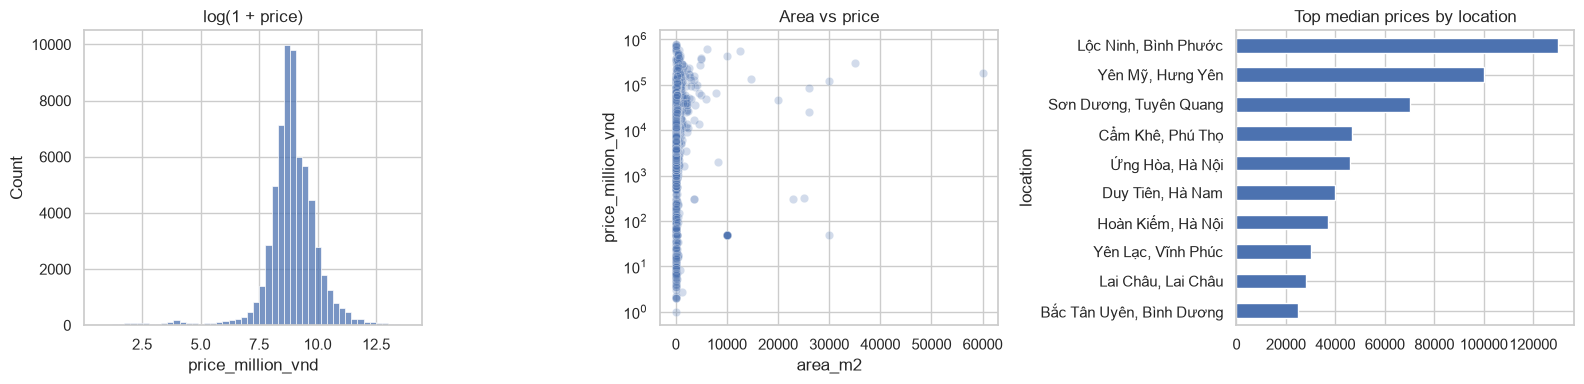

Observation: price lệch phải, location tạo phân vùng mạnh, quan hệ area-price có outlier.
ML implication: log-target + one-hot + early stopping; test thêm baseline dạng cây.


In [4]:
sample=df.sample(min(15000,len(df)),random_state=SEED)
fig,ax=plt.subplots(1,3,figsize=(16,4))
sns.histplot(np.log1p(df[target]),bins=50,ax=ax[0]); ax[0].set_title("log(1 + price)")
sns.scatterplot(data=sample,x="area_m2",y=target,alpha=.25,ax=ax[1]); ax[1].set_yscale("log"); ax[1].set_title("Area vs price")
df.groupby("location")[target].median().nlargest(10).sort_values().plot.barh(ax=ax[2],title="Top median prices by location")
plt.tight_layout(); plt.show()
print("Observation: price lệch phải, location tạo phân vùng mạnh, quan hệ area-price có outlier.")
print("ML implication: log-target + one-hot + early stopping; test thêm baseline dạng cây.")

## 5. Cài đặt MLP 5 tầng, backpropagation và Adam bằng NumPy

In [5]:
def relu(x): return np.maximum(x, 0)
def relu_grad(x): return (x > 0).astype(np.float32)

def init_mlp(layer_dims, seed=42):
    r = np.random.default_rng(seed)
    params = {}
    for i, (din, dout) in enumerate(zip(layer_dims[:-1], layer_dims[1:]), 1):
        params[f"W{i}"] = (r.standard_normal((din, dout)) * np.sqrt(2/din)).astype(np.float32)
        params[f"b{i}"] = np.zeros((1, dout), dtype=np.float32)
    return params

def forward_reg(X, p, return_hidden=False):
    A=X; cache=[]; L=len(p)//2
    for i in range(1,L):
        Z=A@p[f"W{i}"]+p[f"b{i}"]; A_next=relu(Z)
        cache.append((A,Z)); A=A_next
    Z=A@p[f"W{L}"]+p[f"b{L}"]; cache.append((A,Z))
    hidden=[relu(item[1]) for item in cache[:-1]]
    return (Z,cache,hidden) if return_hidden else (Z,cache)

def backward_reg(yhat, y, p, cache):
    n=len(y); L=len(p)//2; grads={}; dZ=2*(yhat-y)/n
    for i in range(L,0,-1):
        A_prev,Z=cache[i-1]
        grads[f"W{i}"]=A_prev.T@dZ
        grads[f"b{i}"]=dZ.sum(axis=0,keepdims=True)
        if i>1: dZ=(dZ@p[f"W{i}"].T)*relu_grad(cache[i-2][1])
    return grads

def adam_step(p,g,state,t,lr=1e-3,b1=.9,b2=.999,eps=1e-8,clip=5.0):
    norm=np.sqrt(sum(float((v*v).sum()) for v in g.values()))
    scale=min(1.0,clip/(norm+1e-12))
    for k in p:
        grad=g[k]*scale; state['m'][k]=b1*state['m'][k]+(1-b1)*grad
        state['v'][k]=b2*state['v'][k]+(1-b2)*(grad*grad)
        mh=state['m'][k]/(1-b1**t); vh=state['v'][k]/(1-b2**t)
        p[k]-=lr*mh/(np.sqrt(vh)+eps)

def train_regression(Xtr,ytr,Xv,yv,dims,lr=1e-3,epochs=20,batch_size=128,patience=6,seed=42):
    p=init_mlp(dims,seed); state={'m':{k:np.zeros_like(v) for k,v in p.items()},'v':{k:np.zeros_like(v) for k,v in p.items()}}
    hist={'train':[],'val':[]}; best=(np.inf,None,0); step=0
    r=np.random.default_rng(seed)
    for epoch in range(epochs):
        for idx in np.array_split(r.permutation(len(Xtr)),max(1,int(np.ceil(len(Xtr)/batch_size)))):
            pred,cache=forward_reg(Xtr[idx],p); g=backward_reg(pred,ytr[idx],p,cache); step+=1
            adam_step(p,g,state,step,lr=lr)
        tr=float(np.mean((forward_reg(Xtr,p)[0]-ytr)**2)); va=float(np.mean((forward_reg(Xv,p)[0]-yv)**2))
        hist['train'].append(tr); hist['val'].append(va)
        if va<best[0]-1e-5: best=(va,copy.deepcopy(p),epoch+1)
        elif epoch+1-best[2]>=patience: break
    return best[1],hist,best[2]

## 6. Exercise 1 - chạy kiến trúc 5 tầng 128→64→32→16→1

In [6]:
input_dim=Xtr.shape[1]; dims=[input_dim,128,64,32,16,1]
epochs=12 if FAST_MODE else 40
t0=time.time(); params,hist,best_epoch=train_regression(Xtr,ytr,Xv,yv,dims,lr=.001,epochs=epochs,batch_size=256,patience=6)
print("Architecture:",dims); print("Best epoch:",best_epoch,"time(s):",round(time.time()-t0,2))
print("Final/best validation MSE(log):",min(hist['val']))

Architecture: [257, 128, 64, 32, 16, 1]
Best epoch: 11 time(s): 3.11
Final/best validation MSE(log): 1.0776031017303467


## 7. Training curves và overfitting

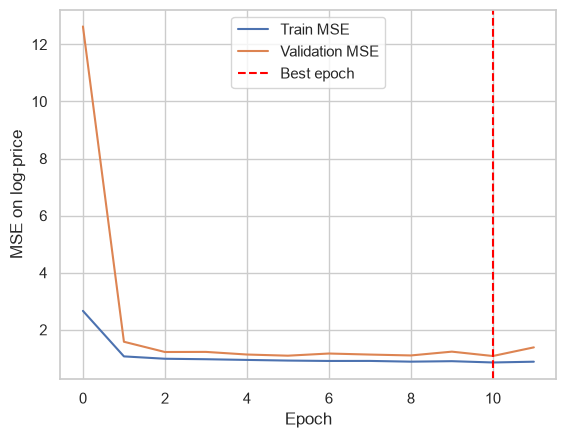

Nếu train loss tiếp tục giảm nhưng validation loss tăng, mô hình đang overfit; early stopping giữ checkpoint tốt nhất.


In [7]:
plt.plot(hist['train'],label="Train MSE"); plt.plot(hist['val'],label="Validation MSE")
plt.axvline(best_epoch-1,color='red',ls='--',label='Best epoch'); plt.xlabel("Epoch"); plt.ylabel("MSE on log-price"); plt.legend(); plt.show()
print("Nếu train loss tiếp tục giảm nhưng validation loss tăng, mô hình đang overfit; early stopping giữ checkpoint tốt nhất.")

## 8. Đánh giá trên đơn vị triệu VND và chống bùng nổ expm1

MAE     7.393851e+03
MSE     1.204534e+09
RMSE    3.470640e+04
R2      6.943097e-02
Name: Deep MLP test, dtype: float64

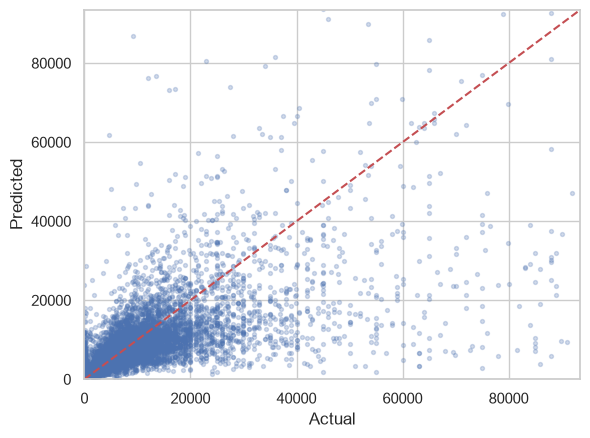

In [8]:
def safe_inverse(z,train_y_log):
    lo,hi=np.quantile(train_y_log,[.001,.999]); return np.expm1(np.clip(z,lo,hi))
pred_log=forward_reg(Xte,params)[0]
actual=np.expm1(yte.ravel()); pred=safe_inverse(pred_log.ravel(),ytr.ravel())
mse=mean_squared_error(actual,pred)
metrics={"MAE":mean_absolute_error(actual,pred),"MSE":mse,"RMSE":np.sqrt(mse),"R2":r2_score(actual,pred)}
display(pd.Series(metrics,name="Deep MLP test"))
lim=np.quantile(np.r_[actual,pred],.99); plt.scatter(actual,pred,s=8,alpha=.25); plt.plot([0,lim],[0,lim],'r--'); plt.xlim(0,lim); plt.ylim(0,lim); plt.xlabel("Actual"); plt.ylabel("Predicted"); plt.show()

## 9. Exercise 2 - đổi learning rate

So sánh $\eta=0.001$ và $0.01$. Learning rate quá lớn có thể dao động; gradient clipping chỉ giảm chứ không xóa hoàn toàn rủi ro.

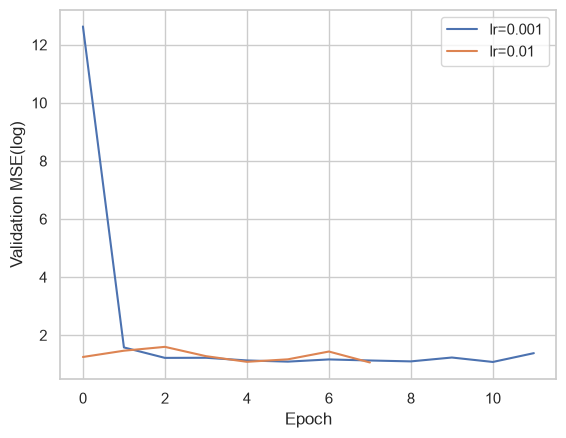

In [9]:
lr_results={.001:(params,hist)}
for lr in [.01]:
    p,h,b=train_regression(Xtr,ytr,Xv,yv,dims,lr=lr,epochs=8 if FAST_MODE else 40,batch_size=256,patience=5)
    lr_results[lr]=(p,h)
for lr,(_,h) in lr_results.items(): plt.plot(h['val'],label=f"lr={lr}")
plt.xlabel("Epoch"); plt.ylabel("Validation MSE(log)"); plt.legend(); plt.show()

## 10. Exercise 3 - giảm độ sâu: 5 tầng so với 3 tầng

In [10]:
shallow_dims=[input_dim,64,16,1]
p_shallow,h_shallow,_=train_regression(Xtr,ytr,Xv,yv,shallow_dims,lr=.001,epochs=8 if FAST_MODE else 40,batch_size=256,patience=5)
print("5-layer best val:",min(hist['val'])); print("3-layer best val:",min(h_shallow['val']))
print("Mạng sâu hơn có capacity lớn hơn nhưng không mặc nhiên tổng quát tốt hơn trên tabular data.")

5-layer best val: 1.0776031017303467
3-layer best val: 1.1480467319488525
Mạng sâu hơn có capacity lớn hơn nhưng không mặc nhiên tổng quát tốt hơn trên tabular data.


## 11. Exercise 4 - inspect learned representations

In [11]:
_,_,hidden=forward_reg(Xtr[:256],params,return_hidden=True)
for i,H in enumerate(hidden,1): print(f"H{i}.shape =",H.shape,"zero fraction =",round(float((H==0).mean()),3))
print("Các tầng nén dần 128→64→32→16; zero fraction phản ánh sparsity do ReLU.")

H1.shape = (256, 128) zero fraction = 0.31
H2.shape = (256, 64) zero fraction = 0.313
H3.shape = (256, 32) zero fraction = 0.48
H4.shape = (256, 16) zero fraction = 0.401
Các tầng nén dần 128→64→32→16; zero fraction phản ánh sparsity do ReLU.


## 12. Baseline Classical ML và đối sánh

In [14]:
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

baselines = {
    "Ridge Regression": Ridge(
        alpha=1.0
    ),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=18,
        min_samples_leaf=3,
        random_state=SEED
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=80,
        max_depth=18,
        min_samples_leaf=3,
        n_jobs=-1,
        random_state=SEED
    )
}

# Kết quả của MLP 5 tầng
rows = [
    {
        "Model": "Deep MLP 5-layer",
        **metrics
    }
]

# Huấn luyện 3 mô hình ML trên giá log
for name, model in baselines.items():
    model.fit(Xtr, ytr.ravel())

    # Dự đoán trên miền log
    predicted_log = model.predict(Xte)

    # Chuyển kết quả về giá thật
    predicted_price = safe_inverse(
        predicted_log,
        ytr.ravel()
    )

    mse = mean_squared_error(
        actual,
        predicted_price
    )

    rows.append({
        "Model": name,
        "MAE": mean_absolute_error(
            actual,
            predicted_price
        ),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(
            actual,
            predicted_price
        )
    })

# RMSE càng nhỏ càng tốt
comparison = (
    pd.DataFrame(rows)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(comparison.round(3))

print(
    "Đối sánh MLP 5 tầng với Ridge Regression, "
    "Decision Tree và Random Forest."
)

,Model,MAE,MSE,RMSE,R2
0,Random Forest,6827.900,1.095211e+09,33093.966,0.154
1,Decision Tree,7734.419,1.163741e+09,34113.645,0.101
2,Deep MLP 5-layer,7393.851,1.204534e+09,34706.397,0.069
3,Ridge Regression,8157.489,1.321814e+09,36356.762,-0.021


Đối sánh MLP 5 tầng với Ridge Regression, Decision Tree và Random Forest.


## 13. Lưu model và preprocessing

In [13]:
artifact={"preprocessor":prep,"params":params,"architecture":dims,"target":"log1p(price_million_vnd)","clip_quantiles":np.quantile(ytr,[.001,.999])}
path=MODEL_DIR/"numpy_mlp_5layers_house.joblib"; joblib.dump(artifact,path); print("Saved:",path)

Saved: C:\Users\hhai6\models\numpy_mlp_5layers_house.joblib


## Tổng kết cần trình bày trong báo cáo

1. Ghi tensor shapes thực tế $B\times d\to B\times128\to B\times64\to B\times32\to B\times16\to B\times1$.
2. Giải thích log-target, one-hot, train-only preprocessing và leakage.
3. Đọc training curves, chỉ ra best epoch/overfitting.
4. Báo cáo MAE, RMSE, $R^2$ trên giá thật; giải thích vì sao `expm1` có thể khuếch đại ngoại suy.
5. Đối sánh MLP với Random Forest bằng kết quả thực tế, không chép số từ PDF mẫu.